### Modified from Modern Computer Vision with Pytorch

In [1]:
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch_snippets import *
from torch_snippets.torch_loader import Report
import matplotlib.pyplot as plt
#!wget -q https://www.dropbox.com/s/ua1rr8btkmpqjxh/face-detection.zip
#!unzip -q face-detection.zip
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Define the Dataset class to read pairs of images and define label 0 (same class) or 1 (different classes)

In [2]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, folder, transform=None, should_invert=True):
        self.folder = folder
        self.items = Glob('{}/*/*'.format(self.folder)) 
        self.transform = transform
    def __getitem__(self, ix):
        itemA = self.items[ix]
        person = fname(parent(itemA))
        same_person = randint(2)
        if same_person:
            itemB = choose(Glob('{}/{}/*'.format(self.folder,person), silent=True))
        else:
            while True:
                itemB = choose(self.items)
                if person != fname(parent(itemB)):
                    break
        imgA = read(itemA)
        imgB = read(itemB)
        if self.transform:
            imgA = self.transform(imgA)
            imgB = self.transform(imgB)
        return imgA, imgB, np.array([1-same_person])
    def __len__(self):
        return len(self.items)


### Create the dataloaders for training and validation

In [3]:
from torchvision import transforms

trn_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(5, (0.01,0.2),
                            scale=(0.9,1.1)),
    transforms.Resize((100,100)),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((100,100)),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

trn_ds = SiameseNetworkDataset(folder="../images/faces/training", transform=trn_tfms)
val_ds = SiameseNetworkDataset(folder="../images/faces/testing", transform=val_tfms)

trn_dl = DataLoader(trn_ds, shuffle=True, batch_size=32)
val_dl = DataLoader(val_ds, shuffle=False, batch_size=32)

### Define a Siamese network architecture

In [4]:
def convBlock(ni, no):
    return nn.Sequential(
        nn.Conv2d(ni, no, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(no),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
    )

In [5]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.features = nn.Sequential(
            convBlock(3,32),
            convBlock(32,128),
            convBlock(128,256),
            nn.Flatten(),
            nn.Linear(256*13*13, 512), 
            nn.ReLU(inplace=True),
            nn.Linear(512, 64)
        )

    def forward(self, input1, input2):
        output1 = self.features(input1)
        output2 = self.features(input2)
        return output1, output2

### Define a contrastive loss function

In [6]:
contrastive_thres = 0.9

class ContrastiveLoss(nn.Module):
    """
    Contrastive loss function.
    Based on: http://yann.lecun.com/exdb/publis/pdf/hadsell-chopra-lecun-06.pdf
    """

    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
    def forward(self, output1, output2, label):
        euclidean_distance = nn.functional.pairwise_distance(output1, output2, keepdim = True)
        loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2)/2 +
            (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))/2
        acc = ((euclidean_distance > contrastive_thres) == label).float().mean()
        return loss_contrastive, acc

### Define the training and validation functions

In [7]:
def train_batch(model, data, optimizer, criterion):
    imgsA, imgsB, labels = [t.to(device) for t in data]
    optimizer.zero_grad()
    codesA, codesB = model(imgsA, imgsB)
    loss, acc = criterion(codesA, codesB, labels)
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_batch(model, data, criterion):
    imgsA, imgsB, labels = [t.to(device) for t in data]
    codesA, codesB = model(imgsA, imgsB)
    loss, acc = criterion(codesA, codesB, labels)
    return loss.item(), acc.item()

### Create the model and define its hiperparameters

In [8]:
model     = SiameseNetwork().to(device)
criterion = ContrastiveLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001, weight_decay=0.01)

### Train and evaluate the model 

In [ ]:
n_epochs = 200
log = Report(n_epochs)

for epoch in range(n_epochs):
    N = len(trn_dl)
    for i, data in enumerate(trn_dl):
        loss, acc = train_batch(model, data, optimizer, criterion)
        log.record(epoch+(1+i)/N, trn_loss=loss, trn_acc=acc, end='\r')
    N = len(val_dl)
    for i, data in enumerate(val_dl):
        loss, acc = validate_batch(model, data, criterion)
        log.record(epoch+(1+i)/N, val_loss=loss, val_acc=acc, end='\r')
    if (epoch+1)%20==0: log.report_avgs(epoch+1)

### Report the results: underfitting occurs due to the small size of the validation set and oscillation indicates insufficient number of examples

100%|██████████| 301/301 [00:00<00:00, 9124.44it/s]


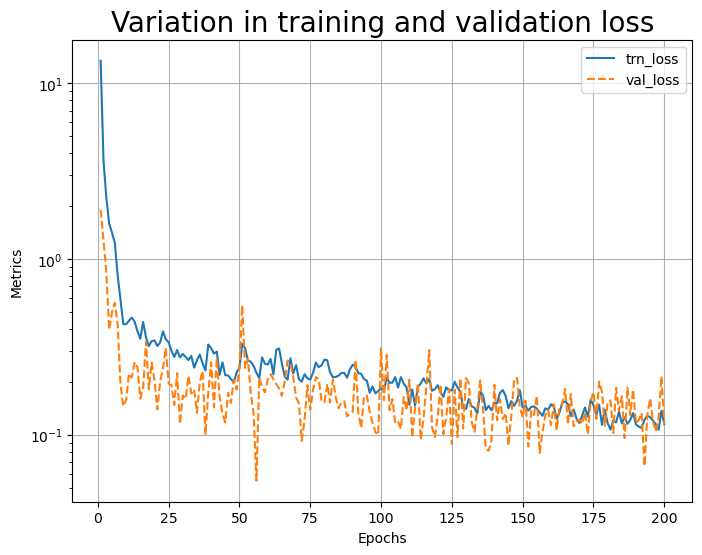

100%|██████████| 301/301 [00:00<00:00, 8771.34it/s]


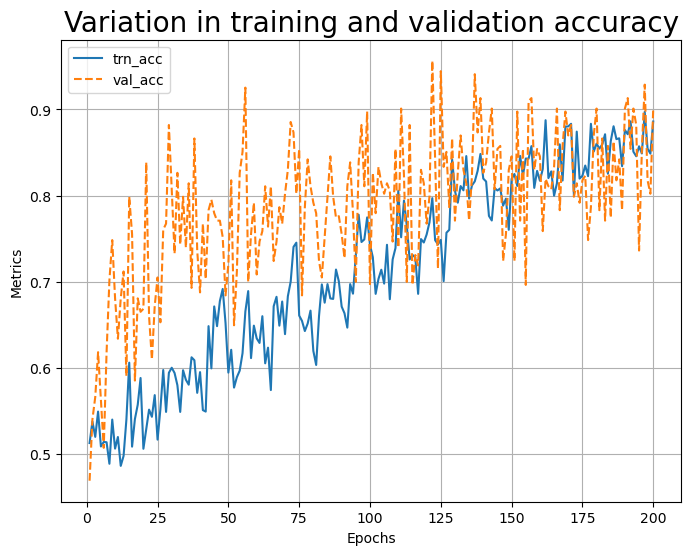

In [10]:
log.plot_epochs(['trn_loss', 'val_loss'], log=True, title='Variation in training and validation loss')
log.plot_epochs(['trn_acc', 'val_acc'], title='Variation in training and validation accuracy')

### Generate the distance histograms of each class: You must set the contrastive threshold to the value that minimizes the classification error, which is at the point the histogram profiles meet each other. Ideally, they should be separated. 

In [11]:
# Distance histograms for the cases we have the same and different persons, respectively. 
different = []
same      = []
model.eval()

for ix, data in enumerate(trn_dl):
    if (ix + 1)%100 == 0:
        print('Processing batch {}/{}'.format((ix + 1), len(trn_dl)))
    imgsA, imgsB, labels = [t.to(device) for t in data]
    codesA, codesB       = model(imgsA, imgsB)
    labels               = labels.cpu()
    
    with torch.no_grad():
        euclidean_distance        = nn.functional.pairwise_distance(codesA, codesB)
        euclidean_distance        = euclidean_distance.cpu()
        
    for i in range(len(labels)): 
        if (labels[i] == 0): # same person
            same.append(euclidean_distance[i].item())
        else:
            different.append(euclidean_distance[i].item())          

                    INFO     Chose `../images/faces/training/s11/6.pgm` from input                                                                      ]8;id=278007;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=607925;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

                    INFO     Chose `../images/faces/training/s34/7.pgm` from input                                                                      ]8;id=677235;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=995420;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

                    INFO     Chose `../images/faces/training/s8/1.pgm` from input                                                                       ]8;id=299864;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=824527;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

                    INFO     Chose `../images/faces/training/s13/5.pgm` from input                                                                      ]8;id=920898;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=494986;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

                    INFO     Chose `../images/faces/training/s15/5.pgm` from input                                                                      ]8;id=520672;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=789546;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

...

                    INFO     Chose `../images/faces/training/s27/5.pgm` from input                                                                      ]8;id=651479;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=180753;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

                    INFO     Chose `../images/faces/training/s35/5.pgm` from input                                                                      ]8;id=635528;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=620332;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

                    INFO     Chose `../images/faces/training/s8/1.pgm` from input                                                                       ]8;id=190412;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=671530;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

                    INFO     Chose `../images/faces/training/s33/9.pgm` from input                                                                      ]8;id=432207;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=941959;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

                    INFO     Chose `../images/faces/training/s30/6.pgm` from input                                                                      ]8;id=55695;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187\loader.py]8;;\:]8;id=830261;file:///opt/conda/envs/deep-learning/lib/python3.12/site-packages/torch_snippets/loader.py:187#choose:187\choose:187]8;;\

[]

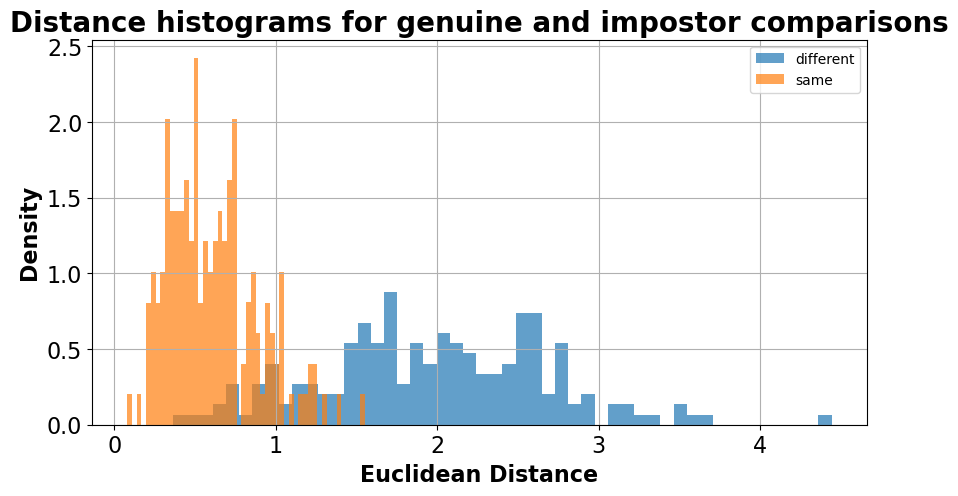

In [12]:
fig, ax = plt.subplots(figsize = (10,5))
ax.set_title('Distance histograms for genuine and impostor comparisons', fontsize = 20, fontweight = 'bold')
ax.set_xlabel('Euclidean Distance', fontsize = 16, fontweight = 'bold')
ax.set_ylabel('Density', fontsize = 16, fontweight = 'bold')
ax.hist(different,bins = 50, density=True, alpha = 0.7, label = 'different')
ax.hist(same, bins = 50, density=True, alpha = 0.7, label = 'same')
ax.tick_params(labelsize = 16, axis = 'both')
ax.legend()
ax.grid(True)
plt.plot()

### Evaluate the model with random choices of image pairs

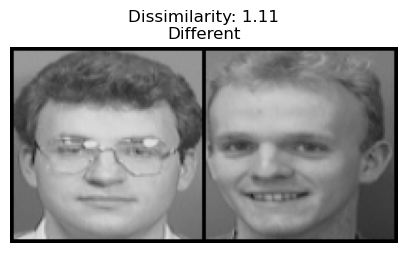

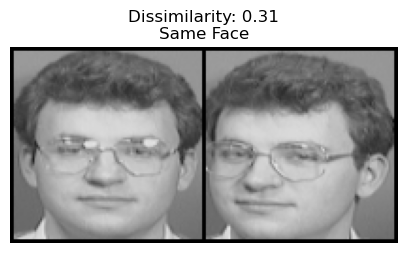

In [13]:
model.eval()
val_dl = DataLoader(val_ds,num_workers=6,batch_size=1,shuffle=True)
dataiter = iter(val_dl)
x0, _, _ = next(dataiter)

for i in range(2):
    _, x1, label2 = next(dataiter)
    concatenated = torch.cat((x0*0.5+0.5, x1*0.5+0.5),0)
    output1,output2 = model(x0.cuda(),x1.cuda())
    euclidean_distance = nn.functional.pairwise_distance(output1, output2)
    output = 'Same Face' if euclidean_distance.item() <= contrastive_thres else 'Different'
    show(torchvision.utils.make_grid(concatenated),
         title='Dissimilarity: {:.2f}\n{}'.format(euclidean_distance.item(), output))
    plt.show()

#### Exercise: Play with the network architecture, contrastive threshold, and other contrastive loss functions (e.g., triplet loss) to improve results without overfitting and underfitting. 